# Plagiarism Detector — 01 EDA

Plagiarism detection ≈ finding near-duplicate / paraphrased text. We use the **MRPC** corpus — sentence pairs labelled *paraphrase* (1) or *not* (0) — as a realistic, labelled proxy. This notebook explores the pairs.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import utils
df=utils.load_pairs()
print('pairs:',len(df),'| paraphrase rate: %.2f'%df.is_paraphrase.mean())
df.head(3)

pairs: 3668 | paraphrase rate: 0.67


,text1,text2,is_paraphrase
0,"Amrozi accused his brother , whom he called "" ...","Referring to him as only "" the witness "" , Amr...",1
1,Yucaipa owned Dominick 's before selling the c...,Yucaipa bought Dominick 's in 1995 for $ 693 m...,0
2,They had published an advertisement on the Int...,"On June 10 , the ship 's owners had published ...",1


## 1. Example pairs

In [2]:
for _,r in df[df.is_paraphrase==1].head(2).iterrows(): print('[PARAPHRASE]\n  A:',r.text1[:90],'\n  B:',r.text2[:90],'\n')
for _,r in df[df.is_paraphrase==0].head(2).iterrows(): print('[NOT]\n  A:',r.text1[:90],'\n  B:',r.text2[:90],'\n')

[PARAPHRASE]
  A: Amrozi accused his brother , whom he called " the witness " , of deliberately distorting h 
  B: Referring to him as only " the witness " , Amrozi accused his brother of deliberately dist 

[PARAPHRASE]
  A: They had published an advertisement on the Internet on June 10 , offering the cargo for sa 
  B: On June 10 , the ship 's owners had published an advertisement on the Internet , offering  

[NOT]
  A: Yucaipa owned Dominick 's before selling the chain to Safeway in 1998 for $ 2.5 billion . 
  B: Yucaipa bought Dominick 's in 1995 for $ 693 million and sold it to Safeway for $ 1.8 bill 

[NOT]
  A: Around 0335 GMT , Tab shares were up 19 cents , or 4.4 % , at A $ 4.56 , having earlier se 
  B: Tab shares jumped 20 cents , or 4.6 % , to set a record closing high at A $ 4.57 . 



## 2. Do similar texts get flagged? (TF-IDF cosine by label)

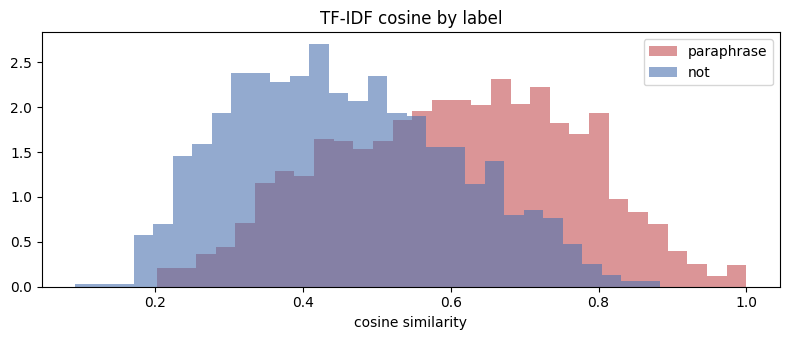

mean cosine — paraphrase 0.604 vs not 0.455


In [3]:
df=utils.score_pairs(df)
fig,ax=plt.subplots(figsize=(8,3.5))
ax.hist(df[df.is_paraphrase==1].tfidf_cosine,bins=30,alpha=0.6,label='paraphrase',color='#c44e52',density=True)
ax.hist(df[df.is_paraphrase==0].tfidf_cosine,bins=30,alpha=0.6,label='not',color='#4c72b0',density=True)
ax.set_title('TF-IDF cosine by label'); ax.set_xlabel('cosine similarity'); ax.legend(); plt.tight_layout(); plt.show()
print('mean cosine — paraphrase %.3f vs not %.3f'%(df[df.is_paraphrase==1].tfidf_cosine.mean(),df[df.is_paraphrase==0].tfidf_cosine.mean()))
df.to_csv('data/pairs_scored.csv',index=False)

## 3. Summary

- **3,668 sentence pairs, 67% paraphrase.**
- Paraphrase pairs have **higher TF-IDF cosine on average (0.60 vs 0.46)** — the signal exists, but the distributions overlap, so a single threshold won't be perfect. Notebook 02 tunes it.